波长: 1.3, 光强: 4.03e-14
波长: 3.4, 光强: 3.97e-14
波长: 3.8, 光强: 3.97e-14
波长: 7.0, 光强: 3.97e-14
波长: 7.3, 光强: 3.97e-14
波长: 7.6, 光强: 3.97e-14
波长: 7.9, 光强: 3.97e-14
波长: 8.2, 光强: 3.97e-14
波长: 11.4, 光强: 3.97e-14
波长: 12.3, 光强: 3.97e-14
波长: 14.4, 光强: 4.16e-14
波长: 16.5, 光强: 4.06e-14
波长: 18.5, 光强: 4e-14
波长: 24.6, 光强: 3.98e-14
波长: 26.5, 光强: 3.99e-14
波长: 28.7, 光强: 4.21e-14
波长: 30.9, 光强: 3.99e-14
波长: 31.3, 光强: 3.99e-14
波长: 32.6, 光强: 4.16e-14
波长: 34.6, 光强: 3.99e-14
波长: 34.9, 光强: 3.99e-14
波长: 35.5, 光强: 3.99e-14
波长: 36.1, 光强: 3.99e-14
波长: 36.8, 光强: 3.99e-14
波长: 37.0, 光强: 3.99e-14
波长: 37.3, 光强: 3.99e-14
波长: 38.2, 光强: 4e-14
波长: 38.8, 光强: 4e-14
波长: 39.5, 光强: 4e-14
波长: 40.1, 光强: 4e-14
波长: 41.5, 光强: 4e-14
波长: 41.8, 光强: 4e-14
波长: 42.8, 光强: 4e-14
波长: 43.0, 光强: 4e-14
波长: 43.5, 光强: 4e-14
波长: 44.0, 光强: 4e-14
波长: 44.7, 光强: 4e-14
波长: 45.7, 光强: 4e-14
波长: 46.3, 光强: 4e-14
波长: 47.2, 光强: 4e-14
波长: 48.1, 光强: 4e-14
波长: 48.5, 光强: 4e-14
波长: 49.1, 光强: 4e-14
波长: 50.5, 光强: 4.01e-14
波长: 66.9, 光强: 4.02e-14
波长: 68.5, 光强: 4.01e-14
波长: 

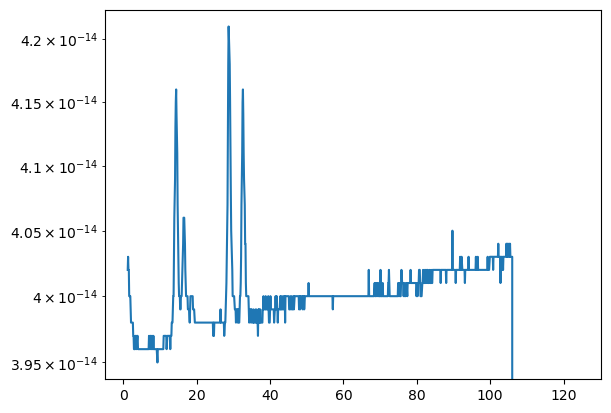

In [14]:
import numpy as np
import pandas as pd
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

# 读取Excel文件
def read_spectral_data(file_path):
    # 跳过前5行，读取数据
    data = pd.read_csv(file_path, skiprows=5)
    wavelengths = data.iloc[:, 0].values  # 波长
    intensities = data.iloc[:, 1].values  # 光强数据
    return wavelengths, intensities

# 寻找峰值
def find_peaks_in_spectrum(wavelengths, intensities, height=None, distance=None, prominence=None, width=None, rel_height=0.5):
    peaks, _ = find_peaks(intensities, height=height, distance=distance, prominence=prominence, width=width, rel_height=rel_height)
    return wavelengths[peaks], intensities[peaks]

# 主函数
def main():
    file_path = 'air1.csv'  # 替换为你的Excel文件路径
    wavelengths, intensities = read_spectral_data(file_path)
    
    # 寻找峰值，可以根据需要调整参数
    peak_wavelengths, peak_intensities = find_peaks_in_spectrum(wavelengths, intensities)
    
    # 打印峰值
    for wl, inten in zip(peak_wavelengths, peak_intensities):
        print(f"波长: {wl}, 光强: {inten}")

    
    # print(wavelengths)
    plt.plot(wavelengths, intensities)
    plt.yscale('log')    
    

if __name__ == "__main__":
    main()

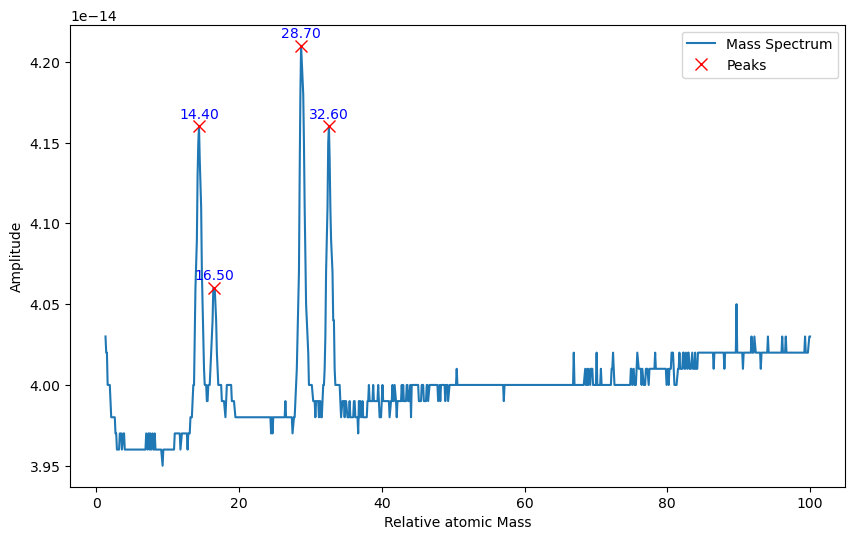

In [34]:
file_path = 'air1.csv'
        
# 读取 .xls 文件，从第7行开始读取
df = pd.read_csv(file_path, header=6)

# 设置峰的高度阈值，调整为适合数据的范围
peak_height = 4.055*1e-14  # 根据你的数据，将阈值设置得更小

# 获取质量和amp数据
mass = df.iloc[:, 0].dropna()
amp = df.iloc[:, 1].dropna()

# 设置横坐标的阈值
mass_threshold = 100  # 假设你想要略去横坐标大于1000的数据

# 过滤数据，只保留横坐标小于或等于阈值的数据
filtered_index = mass <= mass_threshold
mass = mass[filtered_index]
amp = amp[filtered_index]

# 绘制质谱图
plt.figure(figsize=(10, 6))
plt.plot(mass, amp, label='Mass Spectrum')

# 绘制高度阈值线，帮助可视化
# plt.axhline(y=peak_height, color='r', linestyle='--', label='Height threshold')

# 寻峰，调整高度参数
peaks, _ = find_peaks(amp, height=peak_height)

if len(peaks) > 0:
    # 标出峰的位置
    plt.plot(mass[peaks], amp[peaks], "rx", label='Peaks', markersize=8)
    for peak in peaks:
        plt.text(mass[peak], amp[peak] + 0.5e-16, f'{mass[peak]:.2f}', 
                    ha='center', fontsize=10, color='blue')
# else:
#     print(f"No peaks found in {file_name}")

# 添加标题和标签
# plt.title(f'Mass Spectrum of {file_name}')
plt.xlabel('Relative atomic Mass')
plt.ylabel('Amplitude')
plt.legend()

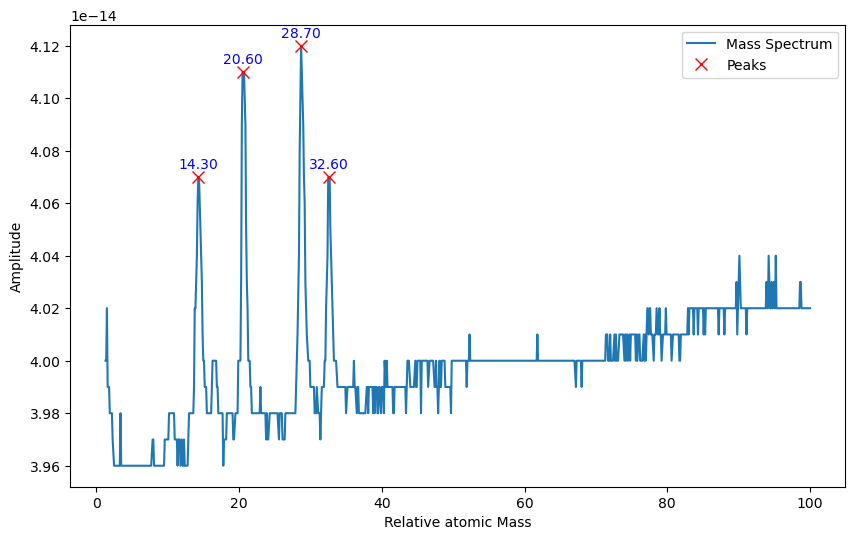

In [39]:
file_path = 'Ne_2.csv'
        
# 读取 .xls 文件，从第7行开始读取
df = pd.read_csv(file_path, header=6)

# 设置峰的高度阈值，调整为适合数据的范围
peak_height = 4.055*1e-14  # 根据你的数据，将阈值设置得更小

# 获取质量和amp数据
mass = df.iloc[:, 0].dropna()
amp = df.iloc[:, 1].dropna()

# 设置横坐标的阈值
mass_threshold = 100  # 假设你想要略去横坐标大于1000的数据

# 过滤数据，只保留横坐标小于或等于阈值的数据
filtered_index = mass <= mass_threshold
mass = mass[filtered_index]
amp = amp[filtered_index]

# 绘制质谱图
plt.figure(figsize=(10, 6))
plt.plot(mass, amp, label='Mass Spectrum')

# 绘制高度阈值线，帮助可视化
# plt.axhline(y=peak_height, color='r', linestyle='--', label='Height threshold')

# 寻峰，调整高度参数
peaks, _ = find_peaks(amp, height=peak_height)

if len(peaks) > 0:
    # 标出峰的位置
    plt.plot(mass[peaks], amp[peaks], "rx", label='Peaks', markersize=8)
    for peak in peaks:
        plt.text(mass[peak], amp[peak] + 0.32e-16, f'{mass[peak]:.2f}', 
                    ha='center', fontsize=10, color='blue')
# else:
#     print(f"No peaks found in {file_name}")

# 添加标题和标签
# plt.title(f'Mass Spectrum of {file_name}')
plt.xlabel('Relative atomic Mass')
plt.ylabel('Amplitude')
plt.legend()

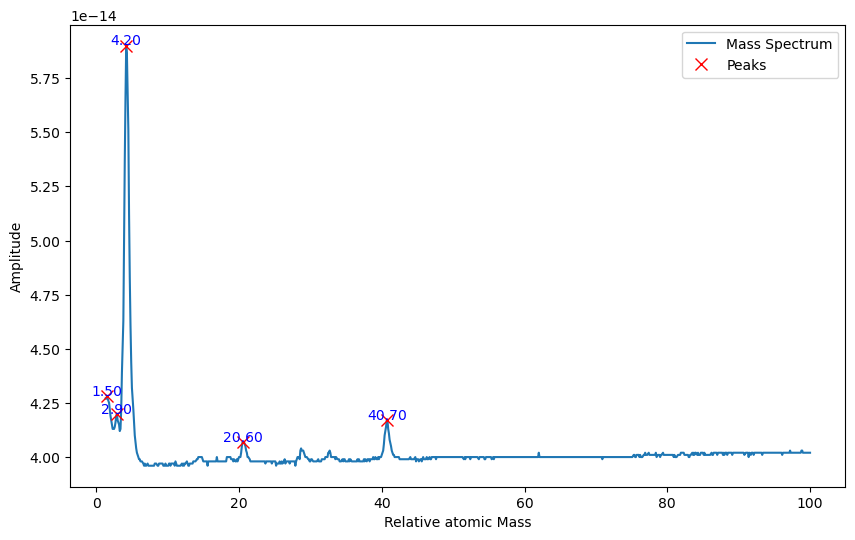

In [40]:
file_path = 'He_2.csv'
        
# 读取 .xls 文件，从第7行开始读取
df = pd.read_csv(file_path, header=6)

# 设置峰的高度阈值，调整为适合数据的范围
peak_height = 4.055*1e-14  # 根据你的数据，将阈值设置得更小

# 获取质量和amp数据
mass = df.iloc[:, 0].dropna()
amp = df.iloc[:, 1].dropna()

# 设置横坐标的阈值
mass_threshold = 100  # 假设你想要略去横坐标大于1000的数据

# 过滤数据，只保留横坐标小于或等于阈值的数据
filtered_index = mass <= mass_threshold
mass = mass[filtered_index]
amp = amp[filtered_index]

# 绘制质谱图
plt.figure(figsize=(10, 6))
plt.plot(mass, amp, label='Mass Spectrum')

# 绘制高度阈值线，帮助可视化
# plt.axhline(y=peak_height, color='r', linestyle='--', label='Height threshold')

# 寻峰，调整高度参数
peaks, _ = find_peaks(amp, height=peak_height)

if len(peaks) > 0:
    # 标出峰的位置
    plt.plot(mass[peaks], amp[peaks], "rx", label='Peaks', markersize=8)
    for peak in peaks:
        plt.text(mass[peak], amp[peak] + 0.32e-16, f'{mass[peak]:.2f}', 
                    ha='center', fontsize=10, color='blue')
# else:
#     print(f"No peaks found in {file_name}")

# 添加标题和标签
# plt.title(f'Mass Spectrum of {file_name}')
plt.xlabel('Relative atomic Mass')
plt.ylabel('Amplitude')
plt.legend()

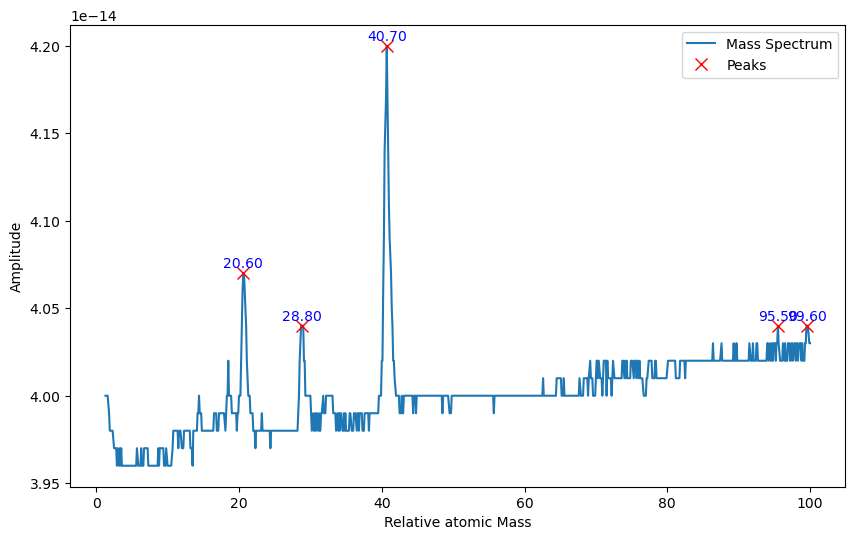

In [50]:
file_path = 'Ar_2.csv'
        
# 读取 .xls 文件，从第7行开始读取
df = pd.read_csv(file_path, header=6)

# 设置峰的高度阈值，调整为适合数据的范围
peak_height = 4.039*1e-14  # 根据你的数据，将阈值设置得更小

# 获取质量和amp数据
mass = df.iloc[:, 0].dropna()
amp = df.iloc[:, 1].dropna()

# 设置横坐标的阈值
mass_threshold = 100  # 假设你想要略去横坐标大于1000的数据

# 过滤数据，只保留横坐标小于或等于阈值的数据
filtered_index = mass <= mass_threshold
mass = mass[filtered_index]
amp = amp[filtered_index]

# 绘制质谱图
plt.figure(figsize=(10, 6))
plt.plot(mass, amp, label='Mass Spectrum')

# 绘制高度阈值线，帮助可视化
# plt.axhline(y=peak_height, color='r', linestyle='--', label='Height threshold')

# 寻峰，调整高度参数
peaks, _ = find_peaks(amp, height=peak_height)

if len(peaks) > 0:
    # 标出峰的位置
    plt.plot(mass[peaks], amp[peaks], "rx", label='Peaks', markersize=8)
    for peak in peaks:
        plt.text(mass[peak], amp[peak] + 0.32e-16, f'{mass[peak]:.2f}', 
                    ha='center', fontsize=10, color='blue')
# else:
#     print(f"No peaks found in {file_name}")

# 添加标题和标签
# plt.title(f'Mass Spectrum of {file_name}')
plt.xlabel('Relative atomic Mass')
plt.ylabel('Amplitude')
plt.legend()